In [1]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier 
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
import matplotlib
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np 
import pandas as pd
import random
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/mirbektoktogaraev/should-this-loan-be-approved-or-denied/SBAnational.csv
/kaggle/input/datasets/mirbektoktogaraev/should-this-loan-be-approved-or-denied/Should This Loan be Approved or Denied A Large Dataset with Class Assignment Guidelines.pdf


In [2]:
random.seed(45)
np.random.seed(45)

The original dataset contains approximately 400,000 rows and 27 attributes. To reduce computational cost and improve iteration speed, we randomly sample 30,000 observations, which will be used as a representative subset for our analysis and modeling.

In [3]:
SBAnational = pd.read_csv("/kaggle/input/datasets/mirbektoktogaraev/should-this-loan-be-approved-or-denied/SBAnational.csv", low_memory=False)

print(SBAnational.head())
# Sampling the data 
SBA_LoanDataSet = SBAnational.sample(n=30000)


   LoanNr_ChkDgt                           Name          City State    Zip  \
0     1000014003                 ABC HOBBYCRAFT    EVANSVILLE    IN  47711   
1     1000024006    LANDMARK BAR & GRILLE (THE)     NEW PARIS    IN  46526   
2     1000034009          WHITLOCK DDS, TODD M.   BLOOMINGTON    IN  47401   
3     1000044001  BIG BUCKS PAWN & JEWELRY, LLC  BROKEN ARROW    OK  74012   
4     1000054004    ANASTASIA CONFECTIONS, INC.       ORLANDO    FL  32801   

                            Bank BankState   NAICS ApprovalDate ApprovalFY  \
0               FIFTH THIRD BANK        OH  451120    28-Feb-97       1997   
1                1ST SOURCE BANK        IN  722410    28-Feb-97       1997   
2        GRANT COUNTY STATE BANK        IN  621210    28-Feb-97       1997   
3  1ST NATL BK & TR CO OF BROKEN        OK       0    28-Feb-97       1997   
4        FLORIDA BUS. DEVEL CORP        FL       0    28-Feb-97       1997   

   ...  RevLineCr  LowDoc  ChgOffDate  DisbursementDate  Disbu

In [4]:
ModdedData = SBA_LoanDataSet.drop(
    columns=[
        "LoanNr_ChkDgt",
        "BalanceGross",
        "Name",
        "ChgOffPrinGr",
        "BankState",
        "ApprovalDate",
        "ChgOffDate",
        "DisbursementDate",
        "Bank",
        "Zip",
        "City"
    ]
)
# Cleaning the data removing "$"
ModdedData["DisbursementGross"] = (ModdedData["DisbursementGross"].str.replace(r'[\$,]', "", 
                                    regex = True).astype(float))
ModdedData["GrAppv"] = (ModdedData["GrAppv"].str.replace(r'[\$,]', "", 
                                    regex = True).astype(float))
ModdedData["SBA_Appv"] = (ModdedData["SBA_Appv"].str.replace(r'[\$,]', "", 
                                    regex = True).astype(float))
# This will be used to map LowDoc and RevLineCr, not able to be used for MIS_Status
binary_Map = { 
    "Y" : 1,
    "N" : 0
}
ModdedDataSet1 = ModdedData
ModdedDataSet1["LowDoc"] = ModdedDataSet1["LowDoc"].map(binary_Map)
ModdedDataSet1["RevLineCr"] = ModdedDataSet1["RevLineCr"].map(binary_Map)
ModdedDataSet1["MIS_Status"] = ModdedDataSet1["MIS_Status"].map({"P I F": 0, "CHGOFF" : 1})
# Only the first 2 numbers have meaningful use
ModdedDataSet1["NAICS"] = ModdedDataSet1["NAICS"].astype(str).str[:2]
# Log these variables for Logisitc Regression
ModdedDataSet1["Log_DisbursementGross"] = np.log1p(ModdedDataSet1["DisbursementGross"])
ModdedDataSet1["log_NoEmp"] = np.log1p(ModdedDataSet1["NoEmp"])
ModdedDataSet1["log_CreateJob"] = np.log1p(ModdedDataSet1["CreateJob"])
ModdedDataSet1["Log_RetainedJob"] = np.log1p(ModdedDataSet1["RetainedJob"])
ModdedDataSet1["Log_GrAppv"] = np.log1p(ModdedDataSet1["GrAppv"])
# Droping NAs from these colmuns
ModdedDataSet1 = ModdedDataSet1.dropna(subset=["RevLineCr"])
ModdedDataSet1 = ModdedDataSet1.dropna(subset=["LowDoc"])
ModdedDataSet1 = ModdedDataSet1.dropna(subset=["NewExist"])
ModdedDataSet1 = ModdedDataSet1.dropna(subset=["MIS_Status"])
ModdedDataSet1 = ModdedDataSet1.drop(columns= [
    "NoEmp", "CreateJob", "RetainedJob", "DisbursementGross"
])

Next we clean the dataset to ensure it is suitable for our case study. The primary objective is to predict loan default, so any variables that do not contribute meaningful predictive information are removed.

First, we eliminate unique identifiers, as these do not provide predictive value and can introduce noise into the model. Next, we address miscellaneous variables, specifically columns with excessive missing values or little practical relevance. For example, variables such as ChgOffDate and ChgOffPrinGr contain predominantly missing values or are mostly recorded as $0.00.

Further exploratory data analysis (EDA) reveals that ChgOffDate has nearly 74% missing values, making it unsuitable. As a result, it is removed from the dataset.

In [5]:
#ModdedDataSet1.describe()
#ModdedDataSet1.shape
#ModdedDataSet1.head()
#ModdedDataSet1.tail()
#SBA_LoanDataSet.info()
#SBA_LoanDataSet.isna().sum().sort_values
#(SBA_LoanDataSet.isna().mean() * 100).round(2)
#SBA_LoanDataSet.corr(numeric_only=True)

As an initial step, we perform a basic time series analysis to observe how default rates change across loan approval years.

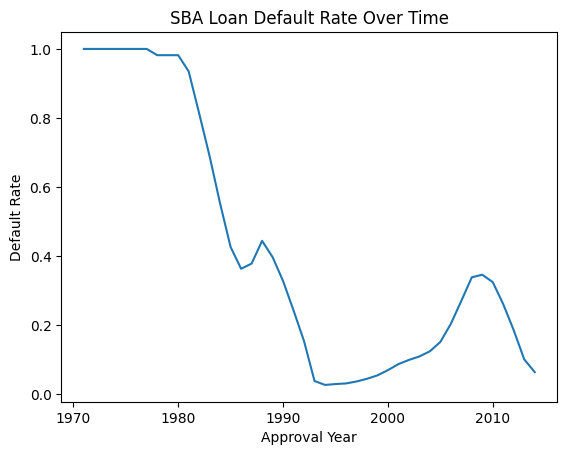

In [6]:
ModdedDataSet1["ApprovalFY"] = ModdedDataSet1["ApprovalFY"].str.replace("A","").astype(int)

loan_ts = (
    ModdedDataSet1
    .groupby("ApprovalFY")
    .agg(total_loan=("MIS_Status","count"),
         defaults=("MIS_Status","sum"))
    .reset_index()
)

loan_ts["default_rate"] = loan_ts["defaults"] / loan_ts["total_loan"]
loan_ts["default_rate_Rolling5y"] = loan_ts["default_rate"].rolling(5, min_periods=1).mean()

loan_ts = loan_ts.sort_values("ApprovalFY")

plt.plot(loan_ts["ApprovalFY"], loan_ts["default_rate_Rolling5y"])
plt.xlabel("Approval Year")
plt.ylabel("Default Rate")
plt.title("SBA Loan Default Rate Over Time")
plt.show()

The data suggests a very high default rate in the 1970s early 1980s, reaching nearly 100% in some years. However, this is likely due to small sample sizes or incomplete historical records, which can distort the observed default rate.

Following this period, there appears to be a sharp decline in default rates, which may reflect changes in SBA lending policies, economic conditions, or improvements in loan screening practices.

Default rates appear to reach their lowest levels during the mid-1990s, suggesting a period of relatively strong loan performance.
After the late 1990s, the data shows a gradual increase in default rates, culminating in a noticeable rise around 2008–2009, which aligns with the global financial crisis. This pattern suggests that broader economic downturn

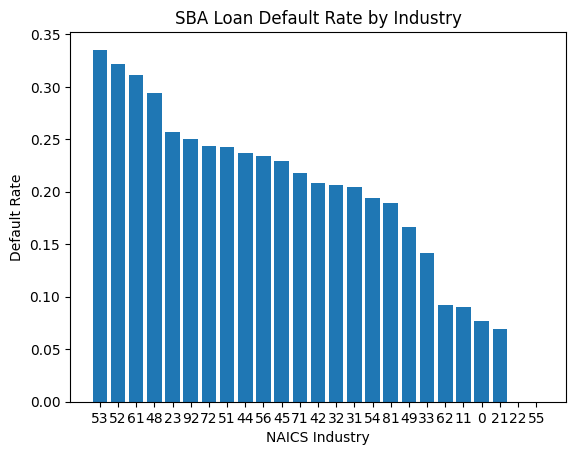

In [7]:
industry_default = ModdedDataSet1.groupby("NAICS").agg(
    total_loans=("MIS_Status","count"),
    defaults=("MIS_Status","sum")
)

industry_default["default_rate"] = (
    industry_default["defaults"] /
    industry_default["total_loans"]
)
industry_default = industry_default.reset_index()
industry_default = industry_default[industry_default["NAICS"] != 0]
industry_default = industry_default.sort_values(
    "default_rate",
    ascending=False
)
#industry_default.sort_values("default_rate", ascending=False)

plt.bar(
    industry_default["NAICS"].astype(str),
    industry_default["default_rate"]
)

plt.xlabel("NAICS Industry")
plt.ylabel("Default Rate")
plt.title("SBA Loan Default Rate by Industry")
plt.show()

**Default Rates by Industry**


Industries with the Highest Default Rates:
55 – Management of Companies and Enterprises
53 – Real Estate and Rental and Leasing
52 – Finance and Insurance
48–49 – Transportation and Warehousing

These industries show the highest default rates. Many businesses in these sectors involve higher capital requirements, financial leverage, or market volatility, which may increase the likelihood of loan default.



Industries with the Lowest Default Rates:
21 – Mining, Quarrying, and Oil and Gas Extraction
11 – Agriculture, Forestry, Fishing and Hunting
62 – Health Care and Social Assistance
33 – Manufacturing

These industries exhibit the lowest default rates. Many of them provide essential goods and services that are consistently demanded, which may contribute to greater financial stability and lower default risk.

In [8]:
# Starting the Logisitc regression 
X = ModdedDataSet1.drop(columns=["MIS_Status"])
y = ModdedDataSet1["MIS_Status"]

# Spliting the data 
X_train, X_test, y_train, y_test = train_test_split (X,y,test_size = 0.2, random_state = 45 , stratify = y)

# 
X_train_lr = pd.get_dummies(
    X_train, 
    columns= [ "State", "UrbanRural", "NAICS"],
    drop_first=True
)
X_test_lr = pd.get_dummies(
    X_test, 
    columns= [ "State", "UrbanRural", "NAICS"],
    drop_first=True
)

X_train_lr, X_test_lr = X_train_lr.align(X_test_lr, join= "left", axis = 1, fill_value= 0)

scale_cols = ["Term" , "Log_DisbursementGross", "log_NoEmp" , "log_CreateJob", "Log_RetainedJob", "Log_GrAppv" ]

scaler = StandardScaler()
X_train_lr[scale_cols] = scaler.fit_transform(X_train_lr[scale_cols])
X_test_lr[scale_cols] = scaler.transform(X_test_lr[scale_cols])

logit = LogisticRegression(
    solver = "lbfgs",
    max_iter=11797,
    random_state = 45)
logit.fit(X_train_lr, y_train)

y_pred_lr = logit.predict(X_test_lr)
y_prob_lr = logit.predict_proba(X_test_lr)[:,1]

print("Accuracy", accuracy_score(y_test, y_pred_lr))
print("ROC AUC: ", roc_auc_score(y_test, y_prob_lr))

Accuracy 0.8627164106315532
ROC AUC:  0.8469342025679225


Logistic Regression

We begin with a logistic regression model, which will serve as the baseline model for this study. The model achieved an accuracy of 0.85 and an ROC–AUC score of 0.84. These results suggest that the model performs very well in predicting loan defaults and is able to reasonably distinguish between default and non-default cases.However, accuracy and ROC–AUC alone are not sufficient to fully evaluate model performance. To better assess the reliability and statistical validity of the model, we will further examine:

Confusion Matrix – to evaluate true positives, false positives, true negatives, and false negatives
Confidence Intervals (CI) – to measure uncertainty in model estimates
p-values – to assess the statistical significance of predictors

These additional diagnostics will provide stronger evidence regarding the model’s predictive power and robustness.

In [9]:
# used for fine tuning
print(X_train_lr.shape)
print(logit.n_iter_)

(16401, 89)
[8532]


We tune the probability threshold used for classification to examine how the model’s performance changes compared to the baseline accuracy metric.

In [10]:
thresholds = np.linspace(.17, .99, 50)

for t in thresholds: 
    y_pred_t = (y_prob_lr >= t).astype(int) 
    acc = accuracy_score(y_test, y_pred_t)
    print(f"Threshold {t:.2f} Accuracy {acc:3}")

threshold = .55
y_pred = (y_prob_lr >= threshold).astype(int)

# confusion matrix
cm = confusion_matrix(y_test,y_pred)
print(cm)

Threshold 0.17 Accuracy 0.7186052182394538
Threshold 0.19 Accuracy 0.7376249695196293
Threshold 0.20 Accuracy 0.7568885637649354
Threshold 0.22 Accuracy 0.7761521580102414
Threshold 0.24 Accuracy 0.7927334796391124
Threshold 0.25 Accuracy 0.8037064130699829
Threshold 0.27 Accuracy 0.8129724457449402
Threshold 0.29 Accuracy 0.8224823213850281
Threshold 0.30 Accuracy 0.8312606681297244
Threshold 0.32 Accuracy 0.8376005852231163
Threshold 0.34 Accuracy 0.83955132894416
Threshold 0.35 Accuracy 0.8471104608632041
Threshold 0.37 Accuracy 0.852962692026335
Threshold 0.39 Accuracy 0.8583272372592051
Threshold 0.40 Accuracy 0.8612533528407705
Threshold 0.42 Accuracy 0.861984881736162
Threshold 0.44 Accuracy 0.8632040965618142
Threshold 0.45 Accuracy 0.8632040965618142
Threshold 0.47 Accuracy 0.8639356254572056
Threshold 0.49 Accuracy 0.861497195805901
Threshold 0.50 Accuracy 0.8622287247012924
Threshold 0.52 Accuracy 0.8597902950499878
Threshold 0.54 Accuracy 0.8573518653986832
Threshold 0.55 A

**Confusion Matrix for Logisitc Regression**

[[3224  117]
 [ 466  277]]

Accuracy = TP + TN / total = ~.86
Precision = TP / TP + FP = .70
Recall = TP / TP + FN = ~.37
F1-score = 2 * (( Precision * Recall) / (Precision + Recall)) = .48

confusion matrix shows that the model correctly identifies most paid loans but misses a significant portion of defaults. While false positives  are relatively low, the number of false negatives is substantial, indicating the model struggles to fully capture default risk.

Based on threshold tuning, a probability threshold between approximately 0.40 and 0.54 appears to provide a decent balance between precision and recall. However, other ML classification will be considered. 

Next, will be finding our CIs, p-values, odds ratio

In [11]:

X_train_numeric = X_train_lr.apply(pd.to_numeric, errors='coerce').fillna(0).values.astype(float)
X_train_const = np.hstack([np.ones((X_train_numeric.shape[0],1)), X_train_numeric])

p = logit.predict_proba(X_train_lr)[:,1]

W = np.diag(p * (1-p)).astype(float)

cov_matrix = np.linalg.inv(X_train_const.T @ W @ X_train_const)

se = np.sqrt(np.diag(cov_matrix)[1:])

coef = logit.coef_[0]


z = stats.norm.ppf(0.975)
CI_lower = np.exp(coef - z*se)
CI_upper = np.exp(coef + z*se)

# Wald-test p-values
p_values = 2 * (1 - stats.norm.cdf(np.abs(coef / se)))

# Odds ratios
OR = np.exp(coef)

# Build table
coef_df = pd.DataFrame({
    'Feature': X_train_lr.columns,
    'Coefficient': coef,
    'OR': OR,
    'CI_lower': CI_lower,
    'CI_upper': CI_upper,
    'p_value': p_values
})

coef_df['OR_percent_change'] = (coef_df['OR'] - 1) * 100

# Top/bottom 5
top5 = coef_df.sort_values('OR_percent_change', ascending=False).head(5)
bottom5 = coef_df.sort_values('OR_percent_change', ascending=True).head(5)

In [12]:
# top5 
bottom5

,Feature,Coefficient,OR,CI_lower,CI_upper,p_value,OR_percent_change
1,Term,-2.031978,0.131076,0.116756,0.147152,0.000000e+00,-86.892398
5,LowDoc,-1.423637,0.240836,0.180220,0.321841,0.000000e+00,-75.916359
4,RevLineCr,-1.214685,0.296803,0.259983,0.338838,0.000000e+00,-70.319660
12,Log_GrAppv,-1.056739,0.347588,0.285871,0.422628,0.000000e+00,-65.241245
84,NAICS_62,-0.875573,0.416623,0.306760,0.565834,2.070730e-08,-58.337658


We examine the odds ratio (OR) from the logisitc regression.

TOP 5
UrbanRural_1 has OR = 3.34, meaning loans in this cateogry are ~234% higher of default
UrbanRural_2 has OR = 2.33, meaning lonas in this categry are ~133% higher of default
States like GA and FL are ~153% and ~141%
This indicate that geographic classification plays a very String role in loan risk.
Log_DisbursementGross has OR = ~2.43 meaning that as the loan amount increase, the odds of default increase ~143%

Bottom5
Term has an OR  = .13 and coefficient of -2.01. this suggests that loans are associated with 87% decrease in pdds of default
LowDoc is associated with 76% decrease in the odds of default
RevLineCr the odds ratio is 0.31, indicating that loans with a revolving line of credit are associated with roughly a 68.9% reduction in default odds.
Log_GrAppv has an odds ratio of 0.34, suggesting that larger loan approvals are associated with approximately a 65.5% decrease in default odds.
Loans in the Health Care and Social Assistance industry have an odds ratio of 0.44, corresponding to about a 55.6% decrease in default odds.

These feature have all very small p-values (<.05) and confidence intervals that do not cross 1, suggesting the effects are statistically significant.

Next is XGBoost, a powerful gradient boosting algorithm to compared to our logistic regression.

In [13]:
X = X_train_lr.copy()
y = y_train.copy()

for col in X.select_dtypes(include=['object']):
    X[col] = X[col].astype('category')
for col in X_test_lr.select_dtypes(include=['object']):
    X_test_lr[col] = X_test_lr[col].astype('category')
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
xgb = XGBClassifier(
    n_estimators = 500,
    max_depth=5,
    learning_rate=.1,
    random_state=42,
    eval_metric = 'logloss',
    enable_categorical = True
)
cv_auc = cross_val_score(
    xgb,
    X,
    y,
    cv = cv,
    scoring="roc_auc",
    error_score='raise'
)
print("XGBoost CV ROC AUC: ", cv_auc)
print("Mean ROC AUC: ", cv_auc.mean())

XGBoost CV ROC AUC:  [0.97468424 0.97194298 0.96814741 0.98140399 0.97099472]
Mean ROC AUC:  0.973434668153193


Our model show very strong perfromace, let's examine further

In [14]:
xgb.fit(X,y)
y_pred_xgb = xgb.predict(X_test_lr)
y_prob_xgb = xgb.predict_proba(X_test_lr)[:,1]

print("XGBoost Test ROC AUC: ", roc_auc_score(y_test,y_prob_xgb))

xgb_importance = pd.DataFrame(
    {
        "Feature": X.columns,
        "importance": xgb.feature_importances_
    }).sort_values(by="importance", ascending= False)

print(xgb_importance.head(10))


perm = permutation_importance(xgb,X_test_lr, y_test, n_repeats=10, random_state=42 )
pd_perm = pd.DataFrame({
    "feature": X_test_lr.columns,
    "importance": perm.importances_mean
}).sort_values(by="importance", ascending= False)

print(pd_perm.head(10))

XGBoost Test ROC AUC:  0.9695794955895546
          Feature  importance
1            Term    0.116769
63   UrbanRural_1    0.071306
0      ApprovalFY    0.059294
3   FranchiseCode    0.032155
21       State_FL    0.025680
4       RevLineCr    0.024943
16       State_CA    0.024863
84       NAICS_62    0.020943
73       NAICS_44    0.016831
43       State_NJ    0.015003
                  feature  importance
1                    Term    0.175591
0              ApprovalFY    0.063302
6                  GrAppv    0.010924
8   Log_DisbursementGross    0.006242
9               log_NoEmp    0.004706
3           FranchiseCode    0.001926
7                SBA_Appv    0.001756
4               RevLineCr    0.001683
63           UrbanRural_1    0.001244
64           UrbanRural_2    0.001024


Term consistently the most important predictor, suggesting loan duration strongly influences default risk.
ApprovalFY indicating that the economic environment at the time of loan approval may impact default probability.
UrbanRural_1 location based factors may affect business stability and loan performance, this tied in with srate indicators. 
RevLineCr and LowDoc suggested taht credit structure and documentation type remain important predictors, consistent with the logistic regression findings.

In [15]:
cm2 = confusion_matrix(y_test,y_pred_xgb)
print(cm2)

[[3277   93]
 [ 148  583]]


**Confusion Matrix for XgBoost**
[[3256   85]
 [ 150  593]]

Accuracy = TP + TN / total = .94
Precision = TP / TP + FP = .87
Recall = TP / TP + FN = ~.80
F1-score = 2 * (( Precision * Recall) / (Precision + Recall)) = .83

With an F1-score of 0.83, the XGBoost model is considered good to very good. It demonstrates a strong balance between precision and recall, effectively identifying both default and paid-off loans while minimizing false positives and false negatives. Overall, the model shows excellent ability to predict both classes accurately. This represents a ~68% reduction in False Negatives. In a lending context, this is the most critical improvement because False Negatives represent high risk borrowers that the model fails to indenity, potenially leading to significant financial loss.